# ⚖️ Módulo 06: Post-Training, Fine-Tuning y el Arte del LLM
## Capítulo 3: Alineamiento de Preferencias: De RLHF Clásico (PPO + Reward Model) a Direct Preference Optimization (DPO)

> *"Alinear un modelo con valores humanos mediante RLHF clásico solía requerir una maquinaria monstruosa y frágil: entrenar un modelo de lenguaje para generar texto, entrenar un modelo de recompensa separado para puntuar respuestas y orquestar un bucle de aprendizaje por refuerzo con PPO manteniendo 4 redes en memoria GPU al mismo tiempo. En 2023, Rafael Rafailov y el equipo de Stanford demostraron analíticamente algo asombroso: el modelo de lenguaje óptimo ya contiene implícitamente su propio modelo de recompensa. Con DPO, el alineamiento se convierte en una simple función de pérdida de entropía cruzada binaria entre respuestas preferidas y rechazadas, erradicando por completo el aprendizaje por refuerzo."*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mcarbonell/algo-to-ai/blob/main/notebooks/06_post_training/03_preference_alignment_dpo.ipynb)

---

### ⚙️ Inicialización del Entorno
Cargamos las librerías matemáticas y fijamos semillas para asegurar reproducibilidad determinista.

In [1]:
# !pip install -q numpy matplotlib torch
from typing import Tuple, List, Dict, Optional
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

np.random.seed(42)
torch.manual_seed(42)
print("✅ Entorno listo para estudiar RLHF y Direct Preference Optimization (DPO) from scratch")

✅ Entorno listo para estudiar RLHF y Direct Preference Optimization (DPO) from scratch


---

## 1. 📜 Contexto Histórico y Proceso de Descubrimiento

### El Nacimiento de RLHF (2017 - 2022)
En 2017, **Paul Christiano, Jan Leike y Dario Amodei** (OpenAI / DeepMind) publicaron *"Deep Reinforcement Learning from Human Preferences"*:
* Observaron que para muchas tareas deseables (ser conciso, educado, verídico o seguro), **es imposible formular una función de pérdida cerrada $L(y, \hat{y})$**.
* Sin embargo, para un ser humano es muy fácil comparar dos opciones y decir: *"La respuesta A es mejor que la respuesta B"*.

### El Complejo Pipeline de Tres Fases de InstructGPT:
1. **Paso 1: Supervised Fine-Tuning (SFT):** Entrenar el modelo base en pares (Prompt, Respuesta).
2. **Paso 2: Modelo de Recompensa (Reward Model):**
   * Mostrar a evaluadores humanos pares $(y_w, y_l)$ donde $y_w$ es la respuesta preferida (*win*) e $y_l$ la rechazada (*lose*).
   * Entrenar una red neuronal $r_\psi(x, y)$ para predecir una puntuación escalar basada en el **Modelo de Bradley-Terry (1952)**:
     $$P(y_w \succ y_l \mid x) = \sigma(r_\psi(x, y_w) - r_\psi(x, y_l))$$
3. **Paso 3: Aprendizaje por Refuerzo con PPO (Proximal Policy Optimization):**
   * Utilizar la recompensa $r_\psi$ para guiar a la política $\pi_\theta$ mediante PPO, añadiendo una penalización de divergencia KL con respecto a una copia de referencia $\pi_{ref}$ para evitar que el modelo "hackee" la recompensa (*reward hacking*).

### La Pesadilla Operativa de PPO:
En memoria GPU se debían cargar **4 modelos simultáneamente**:
1. Política activa $\pi_\theta$ (generación y entrenamiento).
2. Modelo de referencia $\pi_{ref}$ (congelado, cálculo de KL).
3. Modelo de recompensa $r_\psi$ (congelado, asignación de score).
4. Modelo de valor o crítico $V_\phi$ (entrenamiento de ventajas PPO).

¡El consumo de VRAM era exorbitante y el entrenamiento de PPO era célebre por su inestabilidad y propensión al colapso catastrófico!

### El Momento Eureka: DPO (Rafailov et al., Stanford 2023)
En mayo de 2023, **Rafael Rafailov, Archit Sharma, Eric Mitchell, Stefano Ermon, Christopher Manning y Chelsea Finn** publicaron un artículo que transformó la industria:
> *"Direct Preference Optimization: Your Language Model is Secretly a Reward Model"*

Demostraron analíticamente que la política óptima bajo la restricción de divergencia KL permite despejar la recompensa en forma cerrada:
$$r^*(x, y) = \beta \log \frac{\pi_\theta(y \mid x)}{\pi_{ref}(y \mid x)} + \beta \log Z(x)$$

Al sustituir esta expresión en la función de probabilidad de Bradley-Terry, la constante de normalización $\beta \log Z(x)$ **se cancela de forma exacta**.

**Conclusión:** ¡No hace falta ningún modelo de recompensa ni ningún algoritmo de RL! Podemos optimizar directamente los pesos del LLM usando una función de pérdida de clasificación binaria directa sobre pares de preferencias.

---

## 2. 🧠 Intuición Geométrica y Mecánica (Mentalidad de Algoritmista)

### La Función de Pérdida de DPO
$$\mathbf{\mathcal{L}_{DPO}(\theta; \pi_{ref}) = -\mathbb{E}_{(x, y_w, y_l)} \left[ \log \sigma \left( \beta \log \frac{\pi_\theta(y_w \mid x)}{\pi_{ref}(y_w \mid x)} - \beta \log \frac{\pi_\theta(y_l \mid x)}{\pi_{ref}(y_l \mid x)} \right) \right]}$$

Donde definimos la **Recompensa Implícita** aprendida por el modelo como:
$$\mathbf{\hat{r}_\theta(x, y) = \beta \log \frac{\pi_\theta(y \mid x)}{\pi_{ref}(y \mid x)} = \beta \Big( \log \pi_\theta(y \mid x) - \log \pi_{ref}(y \mid x) \Big)}$$

El argumento dentro del Sigmoide no es más que el margen entre ambas recompensas implícitas:
$$\Delta r = \hat{r}_\theta(x, y_w) - \hat{r}_\theta(x, y_l)$$

### La Dinámica del Gradiente:
* Si el modelo actual asigna mayor probabilidad a $y_w$ que a $y_l$ (en comparación con la referencia), $\Delta r$ es grande y positivo $\implies \sigma(\Delta r) \approx 1 \implies \mathcal{L}_{DPO} \approx 0$ (el gradiente se apaga, no hay sobreajuste).
* Si el modelo prefiere erróneamente la respuesta rechazada $y_l$, $\Delta r$ es negativo $\implies$ el gradiente empuja con fuerza para **subir la probabilidad de $y_w$ y bajar la probabilidad de $y_l$**.

---

## 3. 🛠️ Implementación "From Scratch" (Primeros Principios)

Implementemos la función de pérdida `dpo_loss` y el cálculo de log-probabilidades exacto en PyTorch puro.

In [2]:
def dpo_loss(
    policy_chosen_logps: torch.Tensor,
    policy_rejected_logps: torch.Tensor,
    ref_chosen_logps: torch.Tensor,
    ref_rejected_logps: torch.Tensor,
    beta: float = 0.1
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Calcula la perdida de Direct Preference Optimization (DPO).
    
    Args:
        policy_chosen_logps: Log-probabilidad de la respuesta preferida bajo pi_theta (B,)
        policy_rejected_logps: Log-probabilidad de la respuesta rechazada bajo pi_theta (B,)
        ref_chosen_logps: Log-probabilidad de la respuesta preferida bajo pi_ref (B,)
        ref_rejected_logps: Log-probabilidad de la respuesta rechazada bajo pi_ref (B,)
        beta: Factor de penalizacion KL (tipicamente entre 0.05 y 0.5)
        
    Returns:
        loss: Escalar de perdida DPO
        chosen_rewards: Recompensas implicitas de las respuestas preferidas (B,)
        rejected_rewards: Recompensas implicitas de las respuestas rechazadas (B,)
    """
    # 1. Ratios logaritmicos entre politica y referencia
    pi_logratios = policy_chosen_logps - policy_rejected_logps
    ref_logratios = ref_chosen_logps - ref_rejected_logps
    
    # 2. Margen escalado por beta
    logits = beta * (pi_logratios - ref_logratios)
    
    # 3. Perdida DPO: -log(sigmoid(logits)) = F.softplus(-logits) para estabilidad numerica
    losses = -F.logsigmoid(logits)
    
    # 4. Recompensas implicitas para monitoreo (sin gradiente necesario en ref)
    chosen_rewards = beta * (policy_chosen_logps - ref_chosen_logps).detach()
    rejected_rewards = beta * (policy_rejected_logps - ref_rejected_logps).detach()
    
    return losses.mean(), chosen_rewards, rejected_rewards

print("✅ Función dpo_loss compilada exitosamente con logsigmoid numéricamente estable")

✅ Función dpo_loss compilada exitosamente con logsigmoid numéricamente estable


### Cálculo de Log-Probabilidades de Secuencia en Modelos Causales
En un LLM, la log-probabilidad total de una respuesta $y = [y_1, \dots, y_T]$ condicionada por $x$ es la suma de los log-softmax en cada paso:
$$\log P(y \mid x) = \sum_{t=1}^T \log P(y_t \mid x, y_{<t})$$

Implementemos la función que extrae estas log-probabilidades ignorando las posiciones `-100`:

In [3]:
def get_batch_logps(logits: torch.Tensor, labels: torch.Tensor, ignore_index: int = -100) -> torch.Tensor:
    """
    Extrae la suma de log-probabilidades de los tokens no enmascarados.
    
    logits: (Batch, Seq_Len, Vocab_Size)
    labels: (Batch, Seq_Len)
    """
    # Log-softmax a lo largo del vocabulario
    log_probs = F.log_softmax(logits, dim=-1)
    
    # Mascara de posiciones validas
    loss_mask = (labels != ignore_index)
    
    # Reemplazar temporalmente -100 por 0 para poder usar gather sin error
    safe_labels = labels.clone()
    safe_labels[~loss_mask] = 0
    
    # Extraer la log-probabilidad del token correcto en cada posicion
    per_token_logps = torch.gather(log_probs, dim=2, index=safe_labels.unsqueeze(2)).squeeze(2)
    
    # Sumar unicamente sobre los tokens validos de la respuesta
    return (per_token_logps * loss_mask).sum(dim=-1)

print("✅ Función get_batch_logps compilada exitosamente")

✅ Función get_batch_logps compilada exitosamente


### Demostración Práctica: Entrenamiento y Evolución de Recompensas Implícitas
Simulemos un proceso de alineamiento DPO donde un modelo aprende a preferir sistemáticamente respuestas correctas frente a respuestas incorrectas:

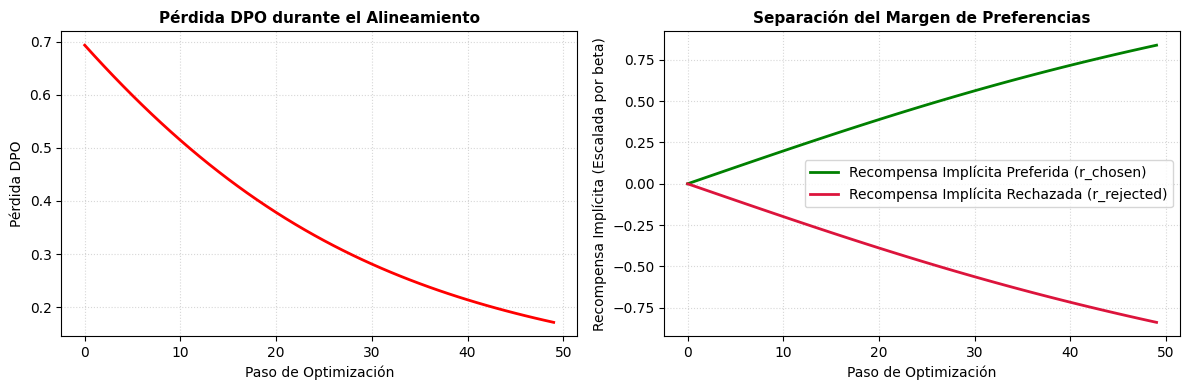

🚀 ¡Observa cómo DPO eleva la recompensa de la respuesta deseada mientras deprime la rechazada!


In [4]:
# Parametros de simulacion
torch.manual_seed(42)
batch_size = 4

# Simulamos las log-probabilidades del modelo de referencia (congelado)
# En el modelo base, ambas respuestas son igualmente plausibles
ref_chosen = torch.tensor([-12.5, -8.2, -15.1, -10.4])
ref_rejected = torch.tensor([-12.3, -8.4, -14.9, -10.5])

# Parametros entrenables de la politica (inicializados identicos a la referencia)
policy_chosen = nn.Parameter(ref_chosen.clone())
policy_rejected = nn.Parameter(ref_rejected.clone())

opt = torch.optim.Adam([policy_chosen, policy_rejected], lr=0.1)
history_chosen_rewards = []
history_rejected_rewards = []
history_loss = []

for step in range(50):
    opt.zero_grad()
    loss, r_chosen, r_rejected = dpo_loss(
        policy_chosen, policy_rejected, ref_chosen, ref_rejected, beta=0.2
    )
    loss.backward()
    opt.step()
    
    history_loss.append(loss.item())
    history_chosen_rewards.append(r_chosen.mean().item())
    history_rejected_rewards.append(r_rejected.mean().item())

# Graficar la divergencia de recompensas y reduccion de perdida
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_loss, 'r-', linewidth=2)
axes[0].set_title('Pérdida DPO durante el Alineamiento', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Paso de Optimización')
axes[0].set_ylabel('Pérdida DPO')
axes[0].grid(True, linestyle=':', alpha=0.5)

axes[1].plot(history_chosen_rewards, 'g-', linewidth=2, label='Recompensa Implícita Preferida (r_chosen)')
axes[1].plot(history_rejected_rewards, 'crimson', linewidth=2, label='Recompensa Implícita Rechazada (r_rejected)')
axes[1].set_title('Separación del Margen de Preferencias', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Paso de Optimización')
axes[1].set_ylabel('Recompensa Implícita (Escalada por beta)')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()
print("🚀 ¡Observa cómo DPO eleva la recompensa de la respuesta deseada mientras deprime la rechazada!")

---

## 4. ⚡ Transición a PyTorch Moderno

En entornos de producción, el alineamiento DPO se ejecuta usando `DPOTrainer` de la librería `TRL` de Hugging Face:

```python
from trl import DPOTrainer, DPOConfig

dpo_config = DPOConfig(
    beta=0.1,             # Penalización KL
    learning_rate=5e-7,   # Los LRs en DPO suelen ser muy pequeños (1e-6 a 5e-7)
    max_length=1024,
    max_prompt_length=512,
    output_dir="./dpo_aligned_model"
)

# El dataset contiene columnas: 'prompt', 'chosen', 'rejected'
trainer = DPOTrainer(
    model=model,             # Política a entrenar
    ref_model=None,          # Si es None, TRL crea automáticamente una copia congelada con PEFT
    args=dpo_config,
    train_dataset=preference_dataset,
    tokenizer=tokenizer
)
trainer.train()
```

---

## 5. 🎯 Retos & Experimentos ("Tinker Time")

### Reto 1: Verificación Manual en NumPy del Margen de Recompensa
Comprobemos que la fórmula manual en NumPy coincide con la implementación de PyTorch:

In [5]:
# Valores de prueba
pi_w, pi_l = -5.0, -8.0
ref_w, ref_l = -6.0, -6.0
beta_val = 0.2

# Recompensas implícitas manuales
r_w_manual = beta_val * (pi_w - ref_w)  # 0.2 * (-5 - (-6)) = 0.2
r_l_manual = beta_val * (pi_l - ref_l)  # 0.2 * (-8 - (-6)) = -0.4
margin_manual = r_w_manual - r_l_manual  # 0.2 - (-0.4) = 0.6
# Pérdida DPO: -log(1 / (1 + exp(-margin))) = log(1 + exp(-margin))
loss_manual = np.log(1.0 + np.exp(-margin_manual))

# PyTorch
l_pt, rw_pt, rl_pt = dpo_loss(
    torch.tensor([pi_w]), torch.tensor([pi_l]),
    torch.tensor([ref_w]), torch.tensor([ref_l]),
    beta=beta_val
)

print(f"Margen manual:       {margin_manual:.4f}")
print(f"Pérdida manual:      {loss_manual:.6f}")
print(f"Pérdida PyTorch:     {l_pt.item():.6f}")
assert np.isclose(loss_manual, l_pt.item(), atol=1e-5)
print("✅ La formulación analítica de la pérdida DPO es numéricamente exacta")

Margen manual:       0.6000
Pérdida manual:      0.437488
Pérdida PyTorch:     0.437488
✅ La formulación analítica de la pérdida DPO es numéricamente exacta


### Reto 2 (Para resolver): Implementar Kahneman-Tversky Optimization (KTO)
En 2024, Kawin Ethayarajh et al. (Stanford) publicaron **KTO**, demostrando que no necesitamos pares de comparaciones $(y_w, y_l)$. En KTO, cada muestra $(x, y)$ se etiqueta de forma independiente como deseable ($y \in \mathcal{D}_w$) o indeseable ($y \in \mathcal{D}_l$):
$$\mathcal{L}_{KTO} = \begin{cases} 1 - \sigma\left(\beta (\log \frac{\pi(y|x)}{\pi_{ref}(y|x)} - z_0)\right) & \text{si } y \text{ es deseable} \\ 1 - \sigma\left(\beta (z_0 - \log \frac{\pi(y|x)}{\pi_{ref}(y|x)})\right) & \text{si } y \text{ es indeseable} \end{cases}$$
Donde $z_0$ es el valor esperado de la recompensa de referencia de Kahneman-Tversky.

Implementa a continuación la función `kto_loss(policy_logps, ref_logps, is_desirable, beta=0.1, z_0=0.0)`:

In [6]:
# TU CÓDIGO DEL RETO 2 AQUÍ
def kto_loss(
    policy_logps: torch.Tensor,
    ref_logps: torch.Tensor,
    is_desirable: torch.Tensor,
    beta: float = 0.1,
    z_0: float = 0.0
) -> torch.Tensor:
    """
    Calcula la pérdida KTO para ejemplos individuales con etiqueta binaria (deseable/indeseable).
    """
    # Tu implementación aquí
    pass

---

## 6. 📚 Referencias Fundamentales & Lecturas Recomendadas

### 📄 Papers Seminales
1. **Rafailov, R., et al. (2023):** *"Direct Preference Optimization: Your Language Model is Secretly a Reward Model"*, NeurIPS 2023. [arXiv:2305.18290](https://arxiv.org/abs/2305.18290)
   * *¿Qué leer?* Sección 4 ("Direct Preference Optimization"): la deducción que cancela la función de partición $Z(x)$.
2. **Christiano, P. F., et al. (2017):** *"Deep Reinforcement Learning from Human Preferences"*, NeurIPS 2017. [arXiv:1706.03741](https://arxiv.org/abs/1706.03741)
   * *¿Qué leer?* El paper fundacional que introdujo el modelo de Bradley-Terry para alinear redes neuronales.
3. **Ethayarajh, K., et al. (2024):** *"KTO: Model Alignment as Prospect Theoretic Optimization"*, ICML 2024. [arXiv:2402.01306](https://arxiv.org/abs/2402.01306)
   * *¿Qué leer?* La conexión entre teoría de la decisión conductual humana (Daniel Kahneman) y alineamiento de LLMs.